# Problem Definition

Our problem can be formulated as a capacitated vehicle routing problem with a single depot, fixed pickup locations, and time-windowed drop-offs. The road network and stop set are given and are not decision variables. Edge travel times are fixed and do not depend on traffic. Consequently, the relevant temporal constraints concern (i) in-vehicle times experienced by students and (ii) arrival deadlines at schools. A fleet of buses, each with fixed passenger capacity and a finite distance-based range (no refueling during operations), departs from and returns to a common depot (currently a single depot, with a possible extension to multiple depots). Students wait at designated stops and must be delivered to their assigned school no later than a specified slack $\delta$ before that school's start time. Additionally, each student must spend at most $1\,\mathrm{h}$ inside a bus. Capacity constraints apply only at the bus level. Furthermore, service times are modeled explicitly as each boarding event incurs a fixed dwell time of $0.3$ minutes per student, and each alighting event at a school incurs $0.5$ minutes per student. Buses are not dedicated to a particular school and may serve multiple schools on a single tour, provided that all students are delivered to their own school and no inter-bus transfers are permitted. A subset of students is flagged as requiring additional on-board support which is provided by a _monitor_ who is themselves a staff member riding to school. Feasibility requires that the monitor be picked up prior to the first boarding of any flagged student.

To simplify the routing problem, we do not consider for the pickup students that live within a certain distance $\gamma$ from their school. Furthermore, we reduce the real-world street graph to reflect only the shortest paths between the depot, schools, and stops.


In [60]:
import networkx as nx
import matplotlib.pyplot as plt
import cvxpy as cp
import random

from functools import cache

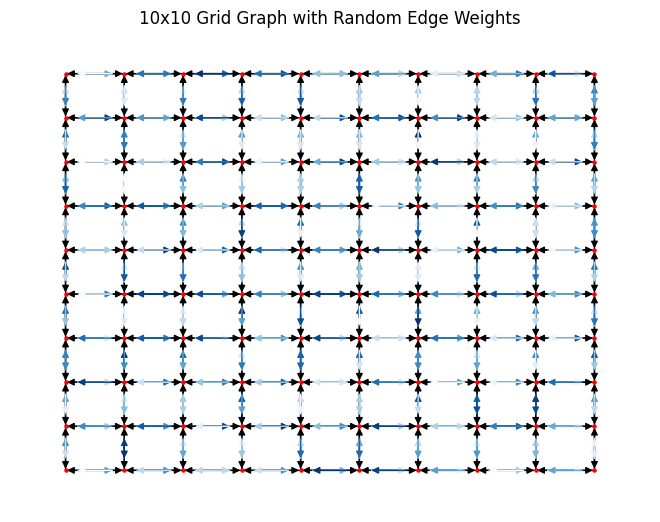

In [61]:
SIZE = 10

# set up a 20 x 20 grid graph
G: nx.Graph = nx.grid_2d_graph(SIZE, SIZE, create_using=nx.DiGraph)

# assign random weights to the edges
for u, v in G.edges():
    G.edges[u, v]["weight"] = random.random()

# visualize the graph
pos = {(x, y): (x, y) for x, y in G.nodes()}
weights = nx.get_edge_attributes(G, "weight")

nx.draw(G, pos, with_labels=False, node_size=5, node_color="red")
# color edges by weight
nx.draw_networkx_edges(
    G, pos, edge_color=list(weights.values()), edge_cmap=plt.cm.Blues
)

plt.title(f"{SIZE}x{SIZE} Grid Graph with Random Edge Weights")
plt.show()

In [62]:
from attr import dataclass
from enum import IntEnum


class SchoolType(IntEnum):
    ELEMENTARY = 0
    MIDDLE = 1
    HIGH = 2


@dataclass(frozen=True)
class Stop:
    name: str
    location: tuple[int, int]


@dataclass(frozen=True)
class Depot:
    name: str
    location: tuple[int, int]


@dataclass(frozen=True)
class School:
    name: str
    location: tuple[int, int]
    type: SchoolType
    start_time: int  # in minutes from midnight


@dataclass(frozen=True)
class Bus:
    id: int
    capacity: int
    range: int
    has_wheelchair_access: bool
    depot: Depot


@dataclass(frozen=True)
class Student:
    name: str
    location: tuple[int, int]
    school: School
    stop: Stop
    requires_monitor: bool
    requires_wheelchair: bool

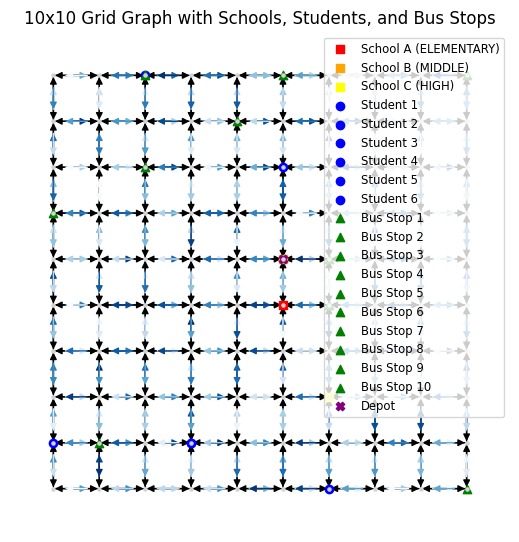

In [63]:
# add 5 schools at random positions, each either elementary, middle, or high school
school_names = ["School A", "School B", "School C", "School D", "School E"]
schools: list[School] = []
for i in range(3):
    school = School(
        name=school_names[i],
        location=(random.randint(0, SIZE - 1), random.randint(0, SIZE - 1)),
        type=SchoolType(i) if i < 3 else random.choice(list(SchoolType)),
        start_time=random.randint(
            7 * 60, 9 * 60
        ),  # schools start between 7 and 9 AM in minutes from midnight
    )
    schools.append(school)

# add 20 bus stops at random positions
bus_stops: list[Stop] = []
for i in range(10):
    x_pos = random.randint(0, SIZE - 1)
    y_pos = random.randint(0, SIZE - 1)

    # make sure bus stops don't overlap with schools
    while any(school.location == (x_pos, y_pos) for school in schools):
        x_pos = random.randint(0, SIZE - 1)
        y_pos = random.randint(0, SIZE - 1)

    bus_stops.append(Stop(name=f"Bus Stop {i+1}", location=(x_pos, y_pos)))

# depots
depots: list[Depot] = [Depot(name="Depot", location=(SIZE // 2, SIZE // 2))]

# visualize the graph with schools, students, and bus stops
plt.figure(figsize=(SIZE // 2, SIZE // 2))
nx.draw(G, pos, with_labels=False, node_size=5, node_color="lightgray")
# color edges by weight
nx.draw_networkx_edges(
    G, pos, edge_color=list(weights.values()), edge_cmap=plt.cm.Blues
)
# plot schools, students, and bus stops
school_colors = {
    SchoolType.ELEMENTARY: "red",
    SchoolType.MIDDLE: "orange",
    SchoolType.HIGH: "yellow",
}
for school in schools:
    plt.scatter(
        # color based on type
        school.location[0],
        school.location[1],
        c=school_colors[school.type],
        marker="s",
        label=f"{school.name} ({school.type.name})",
    )


@cache
def get_nearest_stop(location: tuple[int, int]):
    min_distance = float("inf")
    nearest_stop = None
    for stop in bus_stops:
        distance = (
            (location[0] - stop.location[0]) ** 2
            + (location[1] - stop.location[1]) ** 2
        ) ** 0.5
        if distance < min_distance:
            min_distance = distance
            nearest_stop = stop
    return nearest_stop


# add 10 students at random positions, going to random schools
students: list[Student] = []
for i in range(6):
    location = (random.randint(0, SIZE - 1), random.randint(0, SIZE - 1))
    student = Student(
        name=f"Student {i + 1}",
        location=location,
        school=random.choice(schools),
        stop=get_nearest_stop(location),
        requires_monitor=random.choice(
            [True, False, False, False, False]
        ),  # some students require monitoring
        requires_wheelchair=random.choice(
            [True, False, False, False, False, False, False, False, False]
        ),  # some students require wheelchair accessibility
    )
    students.append(student)  # store the student object for later reference

for student in students:
    plt.scatter(
        student.location[0],
        student.location[1],
        c="blue",
        marker="o",
        label=student.name,
    )
for bus_stop in bus_stops:
    plt.scatter(
        bus_stop.location[0],
        bus_stop.location[1],
        c="green",
        marker="^",
        label=bus_stop.name,
    )
for depot in depots:
    plt.scatter(
        depot.location[0], depot.location[1], c="purple", marker="X", label=depot.name
    )

plt.title(f"{SIZE}x{SIZE} Grid Graph with Schools, Students, and Bus Stops")
plt.legend(loc="upper right", fontsize="small")
plt.show()

In [64]:
buses = []
for i in range(6):
    bus = Bus(
        id=i + 1,
        capacity=10,
        range=50,
        # ensure at least buses has wheelchair access
        has_wheelchair_access=(
            True if i < 2 else random.choice([True, False, False, False])
        ),
        depot=random.choice(depots),
    )
    buses.append(bus)

In [65]:
# CONSTANTS

# boarding dwell time per student
ALPHA = 0.3

# alighting dwell time per student
BETA = 0.5

# max ride time in minutes
H_RIDE = 120

# ratio of students served
PHI = 1.0

# non-negative time separation used for precedence
EPSILON = 1e-5

# small nonnegative per-round tie-breaker penalty
LAMBDA_ROUND = 1.0

# capacity multiplier for different school types
KAPPA = {SchoolType.ELEMENTARY: 1.0, SchoolType.MIDDLE: 0.67, SchoolType.HIGH: 0.67}

In [66]:
P: list[Stop] = []  # pickup stop nodes

S: list[School] = []  # school nodes
S_PLUS: list[School] = []  # school start-copy nodes

D: list[Depot] = []  # depot nodes
D_PLUS: list[Depot] = []  # depot start-copy nodes
D_MINUS: list[Depot] = []  # depot end-copy nodes

for bus_stop in bus_stops:
    P.append(bus_stop)


@cache
def make_school_copy(school: School) -> School:
    return School(
        name=school.name + " (copy)",
        location=school.location,
        type=school.type,
        start_time=school.start_time,
    )


for school in schools:
    S.append(school)
    school_copy = make_school_copy(school)
    S_PLUS.append(school_copy)


@cache
def make_depot_copy(depot: Depot, suffix: str) -> Depot:
    return Depot(name=depot.name + f" ({suffix})", location=depot.location)


@cache
def make_depot_start_copy(depot: Depot) -> Depot:
    return make_depot_copy(depot, "start")


@cache
def make_depot_end_copy(depot: Depot) -> Depot:
    return make_depot_copy(depot, "end")


for depot in depots:
    D.append(depot)
    depot_start = make_depot_start_copy(depot)
    depot_end = make_depot_end_copy(depot)
    D_PLUS.append(depot_start)
    D_MINUS.append(depot_end)

type N_TYPE = School | Depot | Stop

N: list[N_TYPE] = P + S + D_PLUS + D_MINUS + S_PLUS


def get_accumulated_time(path: list[tuple[int, int]]) -> float:
    total_time = 0.0
    for i in range(len(path) - 1):
        start_node = path[i]
        end_node = path[i + 1]
        edge_weight = G.edges[start_node, end_node]["weight"]
        total_time += edge_weight
    return total_time


# Directed arcs on the service graph between service nodes.
A: dict[tuple[N_TYPE, N_TYPE], float] = {}
A_PATH: dict[tuple[N_TYPE, N_TYPE], list[tuple[int, int]]] = {}
for start_node in N:
    start_location = start_node.location
    for end_node in N:
        end_location = end_node.location
        if not A.get((start_node, end_node)):
            shortest_path = nx.shortest_path(
                G, source=start_location, target=end_location, weight="weight"
            )
            # set to the weight of the shortest path
            A[(start_node, end_node)] = get_accumulated_time(shortest_path)
            A_PATH[(start_node, end_node)] = shortest_path
        if not A.get((end_node, start_node)):
            shortest_path = nx.shortest_path(
                G, source=end_location, target=start_location, weight="weight"
            )
            # set to the weight of the shortest path
            A[(end_node, start_node)] = get_accumulated_time(shortest_path)
            A_PATH[(end_node, start_node)] = shortest_path

B: list[Bus] = buses

M: list[Student] = students

# students needing monitor, eg special education or wheelchair
F: list[Student] = list(
    filter(lambda s: s.requires_monitor or s.requires_wheelchair, M)
)

# students requiring wheelchair access
W: list[Student] = list(filter(lambda s: s.requires_wheelchair, F))

# school types
TAU = list(SchoolType)

# rounds a bus is allowed to have
Q: list[int] = list(range(1))

# Maximum number of sequential rounds allowed per bus (handpicked).
Q_MAX = len(Q) - 1

In [67]:
@cache
def p_m(m: Student):
    """pickup stop of student m"""
    return m.stop


@cache
def s_m(m: Student):
    """school of student m"""
    return m.school


@cache
def tau_m(m: Student):
    """type of school of student m"""
    return m.school.type


@cache
def f_m(m: Student):
    """1 if student m if flagged"""
    return 1 if m.requires_monitor or m.requires_wheelchair else 0


@cache
def depot_b(b: Bus):
    """depot of bus b"""
    return b.depot


@cache
def C_b(b: Bus):
    """capacity of bus b"""
    return b.capacity


@cache
def Wh_b(b: Bus):
    """1 if bus b has wheelchair access"""
    return 1 if b.has_wheelchair_access else 0


@cache
def R_b(b: Bus):
    """range of bus b in miles"""
    return b.range


@cache
def t_ij(i: N_TYPE, j: N_TYPE) -> float:
    """travel time from node i to node j in minutes"""
    return A[(i, j)]


@cache
def d_ij(i: N_TYPE, j: N_TYPE) -> float:
    """shortest distance from node i to node j in miles, for now same as above"""
    return t_ij(i, j)


@cache
def h_s(s: School):
    """start time of school s in minutes from midnight"""
    return s.start_time


@cache
def slack_s(s: School):
    """required slack time for school s in minutes, same in our case"""
    return 30


@cache
def l_s(s: School):
    """latest allowable arrival time at school s in minutes from midnight"""
    return h_s(s) - slack_s(s)


@cache
def Thorizon():
    """a safe time-horizon upper bound used to bound T_bqi and set Big-M"""
    max_arrival_time = max(l_s(school) for school in schools)
    return max_arrival_time + H_RIDE + 60  # add max ride time and some buffer

In [68]:
# upper bound on bus load
def C_CAP_B(b: Bus):
    """capacity upper bound for bus b, used in big-M constraints"""
    return C_b(b) * max(KAPPA[school.type] for school in schools)


# big-M for time linking
M_TIME = Thorizon()

# big-M for capacity linking
M_CAPACITY = max(C_b(bus) for bus in buses)

# big-M for school type linking
M_TYPE = max(SchoolType)

In [ ]:
# DECISION VARIABLES

z_b = cp.Variable((len(B)), boolean=True)  # 1 if bus b is used (nonempty tour)

z_bq = cp.Variable((len(B), len(Q)), boolean=True)  # 1 if bus b is assigned to round q

y_bqtau = cp.Variable(
    (len(B), len(Q), len(TAU)), boolean=True
)  # 1 if bus b in round q is of type tau

x_bqij = cp.Variable(
    (len(B), len(Q), len(A)), boolean=True
)  # 1 if bus b in round q travels from node i to node j

v_bqi = cp.Variable(
    (len(B), len(Q), len(N)), boolean=True
)  # 1 if bus b in round q visits node i

a_mbq = cp.Variable(
    (len(M), len(B), len(Q)), boolean=True
)  # 1 if student m is assigned to bus b in round q

T_bqi = cp.Variable(
    (len(B), len(Q), len(N)), nonneg=True, bounds=[0, Thorizon()]
)  # time bus b in round q arrives at node i

L_bqi = cp.Variable(
    (len(B), len(Q), len(N)), integer=True, nonneg=True
)  # load of bus b in round q after serving node i

e_bqs = cp.Variable(
    (len(B), len(Q), len(S)), boolean=True
)  # 1 if bus b in round q ends at school s

r_bmon = cp.Variable(
    (len(B)), boolean=True
)  # 1 if bus b as a monitor (ie serves a flagged student)

In [70]:
# COMMON USEFUL DERIVED EXPRESSIONS


def u_pu(b: Bus, q: int, p: Stop) -> cp.Expression:
    """Number boarded at pickup stop p by bus b in round q

    .. math::
        u^{\\mathrm{pu}}_{b,q,p}:=\\sum_{m:\\,p_m=p} a_{mbq}
    """
    return cp.sum([a_mbq[b, q, m] for m in M if p_m(m) == p])


def u_do(b: Bus, q: int, s: School) -> cp.Expression:
    """Number alignted at school s by from b in round q

    .. math::
        u^{\\mathrm{do}}_{b,q,s}:=\\sum_{m:\\,s_m=s} a_{mbq}
    """
    return cp.sum([a_mbq[b, q, m] for m in M if s_m(m) == s])


def svc_p(b: Bus, q: int, p: Stop) -> cp.Expression:
    """Pickup dwell time at stop p in round q

    .. math::
        \\mathrm{svc}_{b,q,p}:=\\alpha\\,u^{\\mathrm{pu}}_{b,q,p}
    """
    return ALPHA * u_pu(b, q, p)


def svc_s(b: Bus, q: int, s: School) -> cp.Expression:
    """Drop-off dwell time at school s in round q

    .. math::
        \\mathrm{svc}_{b,q,s}:=\\beta\\,u^{\\mathrm{do}}_{b,q,s}
    """
    return BETA * u_do(b, q, s)


def c_bqi(b: Bus, q: int, i: tuple[int, int]) -> cp.Expression:
    """Remaining capacity leaving node i in round q

    .. math::
        c_{b,q,i}:=C_b*\\kappa_{\\sigma_{b,q}}-L_{b,q,i}$
    """
    return (
        C_b(b)
        * cp.sum(
            KAPPA[school.type] * y_bqtau[b, q, school.type.value] for school in schools
        )
        - L_bqi[b, q, i]
    )

In [71]:
objective = cp.Minimize(
    cp.sum(
        [
            cp.sum(
                [
                    cp.sum(d_ij(*path) * x_bqij[:, :, ij])
                    for ij, path in enumerate(A.keys())
                ]
            ),
            cp.multiply(LAMBDA_ROUND, cp.sum(z_bq)),
            cp.sum(r_bmon),
        ]
    )
)

constraints: list[cp.Constraint] = []

In [72]:
# STUDENT ASSIGNMENT

# Each student is served by at most one (bus, round)
for m in range(len(M)):
    constraints.append(cp.sum(a_mbq[m, :, :]) <= 1)

# Minimum pickup / coverage requirement
constraints.append(cp.sum(a_mbq[:, :, :]) >= PHI * len(M))

# If student assigned to (b,q), that bus-round is used
for m in range(len(M)):
    for b in range(len(B)):
        for q in range(len(Q)):
            constraints.append(a_mbq[m, b, q] <= z_bq[b, q])

# Round must carry at least one student
for b in range(len(B)):
    for q in range(len(Q)):
        constraints.append(z_bq[b, q] <= cp.sum(a_mbq[:, b, q]))

# If bus is used, it must carry at least one student (in some round)
for b in range(len(B)):
    constraints.append(z_b[b] <= cp.sum(a_mbq[:, b, :]))

In [73]:
# ROUTING / TOUR STRUCTURE

for b, bus in enumerate(B):
    constraints.append(
        cp.sum(
            [
                x_bqij[b, 0, ij]
                for ij, path in enumerate(A.keys())
                if path[0] == make_depot_start_copy(depot_b(bus))
            ]
        )
        == z_bq[b, 0]
    )

for b, bus in enumerate(B):
    for q in range(1, len(Q)):
        constraints.append(
            cp.sum(
                [
                    x_bqij[b, q, ij]
                    for ij, path in enumerate(A.keys())
                    if path[0] == make_depot_start_copy(depot_b(bus))
                ]
            )
            == 0
        )

# round-end school selection (if next round is used, current round must end at exactly one school)
for b in range(len(B)):
    for q in range(len(Q) - 1):
        constraints.append(cp.sum(e_bqs[b, q, :]) == z_bq[b, q + 1])
    constraints.append(cp.sum(e_bqs[b, Q_MAX, :]) == 0)

# start of each round (first starts at depot; rest start at the previous round's end school copy s^+)
for b in range(len(B)):
    for s in range(len(S)):
        # don't use school copy nodes for round 0
        constraints.append(
            cp.sum(
                [
                    x_bqij[b, 0, ij]
                    for ij, path in enumerate(A.keys())
                    if path[0] in S_PLUS
                ]
            )
            == 0
        )
        # if round q > 0 starts at school copy s^+, then round q-1 must end at school s
        for q in range(1, len(Q)):
            constraints.append(
                cp.sum(
                    [
                        x_bqij[b, q, ij]
                        for ij, path in enumerate(A.keys())
                        if path[0] == S_PLUS[s]
                    ]
                )
                == e_bqs[b, q - 1, s]
            )
        for q in range(len(Q)):
            # don't let paths end at school copy s^+
            constraints.append(
                cp.sum(
                    [
                        x_bqij[b, q, ij]
                        for ij, path in enumerate(A.keys())
                        if path[1] == S_PLUS[s]
                    ]
                )
                == 0
            )


for b, bus in enumerate(B):
    for q in range(len(Q) - 1):
        constraints.append(
            cp.sum(
                [
                    x_bqij[b, q, ij]
                    for ij, path in enumerate(A.keys())
                    if path[1] == make_depot_end_copy(depot_b(bus))
                ]
            )
            == z_bq[b, q] - z_bq[b, q + 1]
        )
for b, bus in enumerate(B):
    constraints.append(
        cp.sum(
            [
                x_bqij[b, len(Q) - 1, ij]
                for ij, path in enumerate(A.keys())
                if path[1] == make_depot_end_copy(depot_b(bus))
            ]
        )
        == z_bq[b, len(Q) - 1]
    )

# flow conservation at pickup stops
for b in range(len(B)):
    for q in range(len(Q)):
        for i, node in enumerate(N):
            if node in P:
                constraints.append(
                    cp.sum(
                        [
                            x_bqij[b, q, ij]
                            for ij, path in enumerate(A.keys())
                            if path[0] == node
                        ]
                    )
                    == v_bqi[b, q, i]
                )
                constraints.append(
                    cp.sum(
                        [
                            x_bqij[b, q, ij]
                            for ij, path in enumerate(A.keys())
                            if path[1] == node
                        ]
                    )
                    == v_bqi[b, q, i]
                )

# Stop visit only if someone is assigned from that stop in that round
for b in range(len(B)):
    for q in range(len(Q)):
        for i, node in enumerate(N):
            if node in P:
                constraints.append(
                    v_bqi[b, q, i]
                    <= cp.sum(
                        [
                            a_mbq[m, b, q]
                            for m, student in enumerate(M)
                            if p_m(student) == node
                        ]
                    )
                )

# flow conservation at schools (allow school to be end of a non-last round via e_{b,q,s})
for b in range(len(B)):
    for q in range(len(Q)):
        for i, node in enumerate(N):
            if node in S:
                constraints.append(
                    cp.sum(
                        [
                            x_bqij[b, q, ij]
                            for ij, path in enumerate(A.keys())
                            if path[1] == node
                        ]
                    )
                    == v_bqi[b, q, i]
                )
                constraints.append(
                    cp.sum(
                        [
                            x_bqij[b, q, ij]
                            for ij, path in enumerate(A.keys())
                            if path[0] == node
                        ]
                    )
                    == v_bqi[b, q, i] - e_bqs[b, q, S.index(node)]
                )

for b in range(len(B)):
    for q in range(len(Q)):
        for i, node in enumerate(N):
            if node in S or node in P:
                constraints.append(v_bqi[b, q, i] <= z_bq[b, q])

# Each assigned student forces visiting their pickup and their school (in the same round)
for m, student in enumerate(M):
    for b in range(len(B)):
        for q in range(len(Q)):
            constraints.append(a_mbq[m, b, q] <= v_bqi[b, q, N.index(p_m(student))])
            constraints.append(a_mbq[m, b, q] <= v_bqi[b, q, N.index(s_m(student))])

In [74]:
# TIME ANCHORING
for b, bus in enumerate(B):
    bus_depot = depot_b(bus)
    # make start copy of depot for time anchoring
    bus_start_depot = make_depot_start_copy(bus_depot)
    constraints.append(T_bqi[b, 0, N.index(bus_start_depot)] == 0)

# round-to-round time chaining (start next round at s^+ after finishing previous round at s)
for b in range(len(B)):
    for q in range(1, len(Q)):
        for s, school in enumerate(S):
            constraints.append(
                T_bqi[b, q, N.index(S_PLUS[s])]
                >= T_bqi[b, q - 1, N.index(S[s])]
                + BETA
                * cp.sum(
                    [
                        a_mbq[m, b, q - 1]
                        for m, student in enumerate(M)
                        if s_m(student) == school
                    ]
                )
                - M_TIME * (1 - e_bqs[b, q - 1, s])
            )

In [75]:
# TIME PROPOGATION

# with explicit dwell times
for b in range(len(B)):
    for q in range(len(Q)):
        for ij, path in enumerate(A):
            constraints.append(
                T_bqi[b, q, N.index(path[1])]
                >= T_bqi[b, q, N.index(path[0])]
                + t_ij(*path)
                + ALPHA
                * cp.sum(
                    [
                        a_mbq[m, b, q]
                        for m, student in enumerate(M)
                        if p_m(student) == path[0]
                    ]
                )
                + BETA
                * cp.sum(
                    [
                        a_mbq[m, b, q]
                        for m, student in enumerate(M)
                        if s_m(student) == path[0]
                    ]
                )
                - M_TIME * (1 - x_bqij[b, q, ij])
            )

In [76]:
# SCHOOL LATEST ARRIVAL

# School latest-arrival (delivery-by) constraints
for b in range(len(B)):
    for q in range(len(Q)):
        for school in S:
            constraints.append(
                T_bqi[b, q, N.index(school)]
                + BETA
                * cp.sum(
                    [
                        a_mbq[m, b, q]
                        for m, student in enumerate(M)
                        if s_m(student) == school
                    ]
                )
                <= l_s(school) + M_TIME * (1 - v_bqi[b, q, N.index(school)])
            )

In [77]:
# PICKUP BEFORE DROPOFF AND MAX RIDE TIME

for b in range(len(B)):
    for q in range(len(Q)):
        for m, student in enumerate(M):
            constraints.append(
                T_bqi[b, q, N.index(s_m(student))]
                >= T_bqi[b, q, N.index(p_m(student))]
                + EPSILON
                - M_TIME * (1 - a_mbq[m, b, q])
            )
            constraints.append(
                T_bqi[b, q, N.index(s_m(student))] - T_bqi[b, q, N.index(p_m(student))]
                <= H_RIDE + M_TIME * (1 - a_mbq[m, b, q])
            )

In [78]:
# DISTANCE RANGE CONSTRAINTS

for b, bus in enumerate(B):
    constraints.append(
        cp.sum([d_ij(*path) * x_bqij[b, :, ij] for ij, path in enumerate(A.keys())])
        <= R_b(bus) * z_b[b]
    )

In [79]:
# LOAD / CAPACITY CONSTRAINTS PER ROUND

for b, bus in enumerate(B):
    depot_start = make_depot_start_copy(depot_b(bus))
    depot_end = make_depot_end_copy(depot_b(bus))
    # load at beginning is 0
    constraints.append(L_bqi[b, 0, N.index(depot_start)] == 0)

    for q in range(len(Q)):
        constraints.append(L_bqi[b, q, N.index(depot_end)] == 0)

    for q in range(len(Q)):
        for s, school in enumerate(S):
            constraints.append(L_bqi[b, q, N.index(S_PLUS[s])] == 0)

    for q in range(len(Q)):
        for ij, path in enumerate(A):
            # if a round ends at school s, the bus must be empty after servicing s
            constraints.append(
                L_bqi[b, q, N.index(path[1])]
                >= L_bqi[b, q, N.index(path[0])]
                + cp.sum(
                    [
                        a_mbq[m, b, q]
                        for m, student in enumerate(M)
                        if p_m(student) == path[1]
                    ]
                )
                - cp.sum(
                    [
                        a_mbq[m, b, q]
                        for m, student in enumerate(M)
                        if s_m(student) == path[1]
                    ]
                )
                - M_CAPACITY * (1 - x_bqij[b, q, ij])
            )
            constraints.append(
                L_bqi[b, q, N.index(path[1])]
                <= L_bqi[b, q, N.index(path[0])]
                + cp.sum(
                    [
                        a_mbq[m, b, q]
                        for m, student in enumerate(M)
                        if p_m(student) == path[1]
                    ]
                )
                - cp.sum(
                    [
                        a_mbq[m, b, q]
                        for m, student in enumerate(M)
                        if s_m(student) == path[1]
                    ]
                )
                + M_CAPACITY * (1 - x_bqij[b, q, ij])
            )
            # if a round ends at school s, the bus must be empty after servicing s
    for q in range(len(Q)):
        for i in range(len(N)):
            constraints.append(
                L_bqi[b, q, i]
                <= C_b(bus)
                * cp.sum(
                    [
                        KAPPA[school_type] * y_bqtau[b, q, tau]
                        for tau, school_type in enumerate(TAU)
                    ]
                )
            )
    for q in range(len(Q)):
        for i in range(len(N)):
            constraints.append(L_bqi[b, q, i] >= 0)

    for q in range(len(Q)):
        for s, school in enumerate(S):
            constraints.append(
                L_bqi[b, q, N.index(school)] <= C_CAP_B(bus) * (1 - e_bqs[b, q, s])
            )

In [80]:
# MONITOR FEASIBILITY PER BUS

for b in range(len(B)):
    for q in range(len(Q)):
        # If there are no flagged students, no monitor is needed.
        constraints.append(
            r_bmon[b]
            <= cp.sum(
                [a_mbq[m, b, q] for m, student in enumerate(F) if f_m(student) == 1]
            )
        )
        # If a flag student is on the bus, there should be one monitor
        for m in F:
            constraints.append(r_bmon[b] >= a_mbq[M.index(m), b, q])

In [81]:
# WHEELCHAIR CONSTRAINTS

# if a student requiring a wheelchair is assigned a bus, the bus must be wheelchair-accessible
for m, student in enumerate(W):
    for b, bus in enumerate(B):
        for q in range(len(Q)):
            constraints.append(a_mbq[M.index(student), b, q] <= Wh_b(bus))

In [82]:
# SCHOOL LEVEL

# if a bus is used in a round, it should have a school type assigned to that round,
# and it should match the school type of any student assigned to that bus-round
for b in range(len(B)):
    for q in range(len(Q)):
        constraints.append(cp.sum(y_bqtau[b, q, :]) == z_bq[b, q])
        for m, student in enumerate(M):
            constraints.append(
                a_mbq[m, b, q] <= y_bqtau[b, q, TAU.index(tau_m(student))]
            )

In [83]:
# VARIABLE DOMAINS

# (handled by cvxpy variable definitions)

In [84]:
prob = cp.Problem(objective, constraints)
print("Solving MILP")
try:
    # Try with verbose to see progress; set a reasonable time limit
    prob.solve(
        solver=cp.GLPK_MI,
        verbose=True,
        glpk={"msg_lev": "GLP_MSG_ON", "tm_lim": 2 * 60 * 1000},
    )  # 2-min limit
except Exception as e:
    print(f"⚠️  GLPK_MI failed or unavailable: {e}")
    print("Trying CBC as fallback...")
    try:
        prob.solve(solver=cp.CBC, verbose=True, maximumSeconds=120)
    except Exception as e2:
        print(f"⚠️  CBC also failed: {e2}")
        print("Trying default solver...")
        prob.solve(verbose=True)

print()
print("Status:", prob.status)
print("Objective:", prob.value)

(CVXPY) Mar 16 02:34:44 PM: Your problem has 2358 variables, 6733 constraints, and 0 parameters.


Solving MILP
                                     CVXPY                                     
                                     v1.7.3                                    


(CVXPY) Mar 16 02:34:45 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Mar 16 02:34:45 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Mar 16 02:34:45 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Mar 16 02:34:45 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Mar 16 02:34:47 PM: Compiling problem (target solver=GLPK_MI).
(CVXPY) Mar 16 02:34:47 PM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> GLPK_MI
(CVXPY) Mar 16 02:34:47 PM: Applying reduction Dcp2Cone


-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) Mar 16 02:34:51 PM: Applying reduction CvxAttr2Constr
(CVXPY) Mar 16 02:34:56 PM: Applying reduction ConeMatrixStuffing
d:\superurop\.venv\Lib\site-packages\cvxpy\reductions\solvers\solving_chain_utils.py:41: UserWarning: The problem has an expression with dimension greater than 2. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(
(CVXPY) Mar 16 02:35:12 PM: Applying reduction GLPK_MI
(CVXPY) Mar 16 02:35:12 PM: Finished problem compilation (took 2.661e+01 seconds).
(CVXPY) Mar 16 02:35:12 PM: Invoking solver GLPK_MI  to obtain a solution.


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------


(CVXPY) Mar 16 03:19:14 PM: Problem status: optimal
(CVXPY) Mar 16 03:19:14 PM: Optimal value: 2.641e+01
(CVXPY) Mar 16 03:19:14 PM: Compilation took 2.661e+01 seconds
(CVXPY) Mar 16 03:19:14 PM: Solver (including time spent in interface) took 2.641e+03 seconds


-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------

Status: optimal
Objective: 26.412074423336474


In [85]:
import numpy as np

# Extract and print the route
if prob.status not in [cp.OPTIMAL, cp.OPTIMAL_INACCURATE]:
    print(f"⚠️ Solver did not find a feasible solution (status={prob.status}).")
else:
    for b, bus in enumerate(B):
        print(
            f"\nBus {bus.id} (capacity {C_b(bus)}, range {R_b(bus)}, wheelchair access {Wh_b(bus) == 1}, monitor needed: {r_bmon[b].value > 0.5})"
        )
        for q in range(len(Q)):
            if z_bq[b, q].value > 0.5:
                print(f"  Round {q}:")
                route = []
                students_on_bus = []
                schools_served = []
                for ij, path in enumerate(A.keys()):
                    if x_bqij[b, q, ij].value > 0.5:
                        route.append(path)
                        for node in path:
                            if (
                                node in S
                                and node not in schools_served
                                and any(
                                    a_mbq[m, b, q].value > 0.5 and s_m(M[m]) == node
                                    for m in range(len(M))
                                )
                            ):
                                schools_served.append(node)
                for m, student in enumerate(M):
                    if a_mbq[m, b, q].value > 0.5:
                        students_on_bus.append(student)
                print(
                    f"    Total travel time (excluding dwell): {sum(d_ij(*path) for path in route):.2f} minutes"
                )
                print(
                    f"    Bus type: {TAU[np.argmax(y_bqtau[b,q,:])].name if z_bq[b, q].value > 0.5 else 'N/A'}"
                )
                print(
                    f"    Students on bus this round:\n      {'\n      '.join(str(student) for student in students_on_bus)}"
                )
                print(
                    f"    Schools served:\n      {'\n      '.join(str(school) for school in schools_served)}"
                )

                # Sort route by travel time from depot start
                depot_start = make_depot_start_copy(depot_b(bus))

                # make sure route is in right order, where end of one path is the start of the next
                # ordered_route = []
                # current_node = depot_start
                # while len(ordered_route) < len(route):
                #     for path in route:
                #         if path[0] == current_node:
                #             ordered_route.append(path)
                #             current_node = path[1]
                #             break

                print("    Route:")
                for path in route:
                    print(f"      {path[0]} -> {path[1]}")


Bus 1 (capacity 10, range 50, wheelchair access True, monitor needed: False)
  Round 0:
    Total travel time (excluding dwell): 8.31 minutes
    Bus type: ELEMENTARY
    Students on bus this round:
      Student(name='Student 5', location=(6, 0), school=School(name='School B', location=(5, 5), type=<SchoolType.MIDDLE: 1>, start_time=515), stop=Stop(name='Bus Stop 8', location=(9, 0)), requires_monitor=False, requires_wheelchair=False)
      Student(name='Student 6', location=(3, 1), school=School(name='School B', location=(5, 5), type=<SchoolType.MIDDLE: 1>, start_time=515), stop=Stop(name='Bus Stop 7', location=(1, 1)), requires_monitor=False, requires_wheelchair=False)
    Schools served:
      School(name='School B', location=(5, 5), type=<SchoolType.MIDDLE: 1>, start_time=515)
    Route:
      Stop(name='Bus Stop 7', location=(1, 1)) -> Stop(name='Bus Stop 8', location=(9, 0))
      School(name='School A', location=(5, 4), type=<SchoolType.ELEMENTARY: 0>, start_time=422) -> Stop(

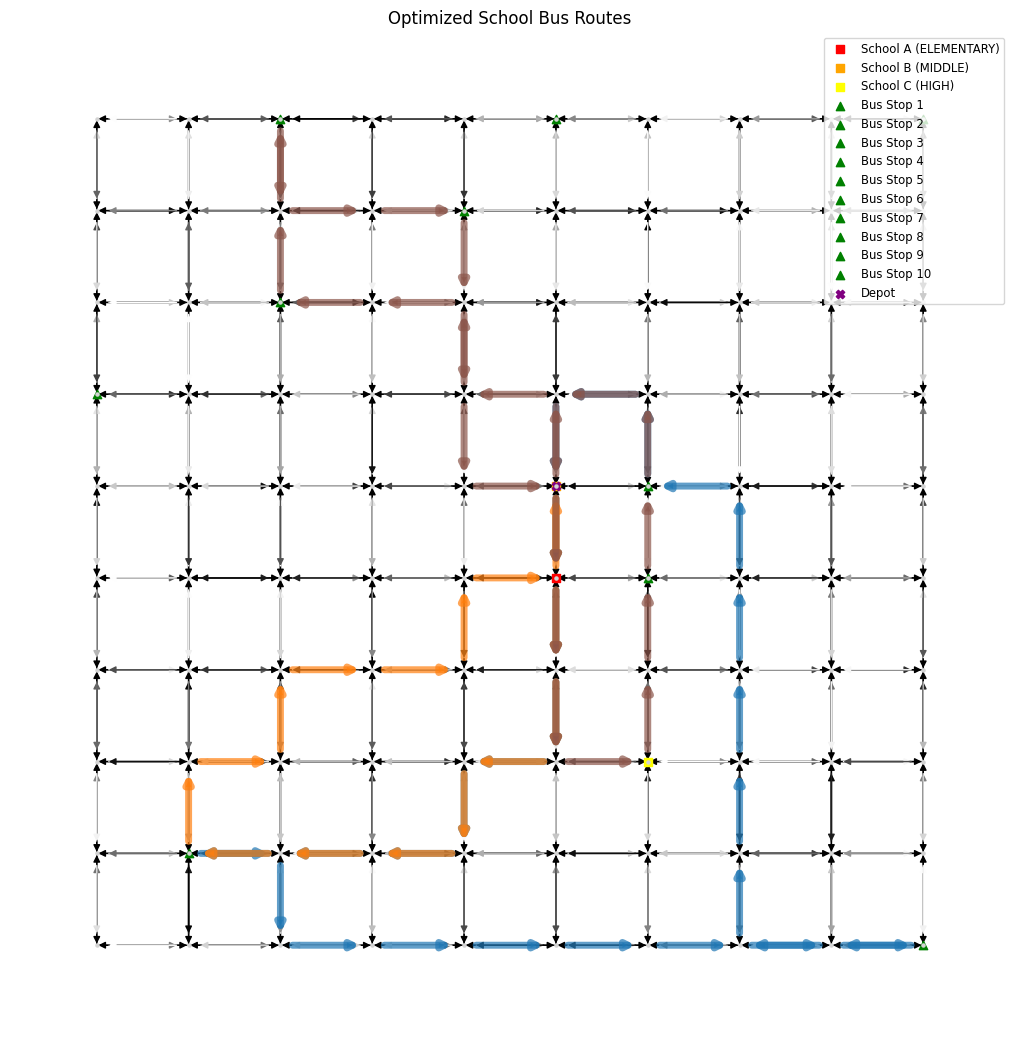

In [86]:
if prob.status not in [cp.OPTIMAL, cp.OPTIMAL_INACCURATE]:
    print("No feasible solution to visualize.")
else:
    # Visualize the routes on the graph
    plt.figure(figsize=(10, 10))
    nx.draw(G, pos, with_labels=False, node_size=5, node_color="lightgray")
    # color edges by weight
    nx.draw_networkx_edges(
        G, pos, edge_color=list(weights.values()), edge_cmap=plt.cm.Grays
    )
    # plot schools, students, and bus stops
    for school in schools:
        plt.scatter(
            school.location[0],
            school.location[1],
            c=school_colors[school.type],
            marker="s",
            label=f"{school.name } ({school.type.name})",
        )
    for bus_stop in bus_stops:
        plt.scatter(
            bus_stop.location[0],
            bus_stop.location[1],
            c="green",
            marker="^",
            label=bus_stop.name,
        )
    for depot in depots:
        plt.scatter(
            depot.location[0],
            depot.location[1],
            c="purple",
            marker="X",
            label=depot.name,
        )
    # plot routes
    colors = plt.colormaps.get_cmap("tab10")
    for b, bus in enumerate(B):
        for q in range(len(Q)):
            if z_bq[b, q].value > 0.5:
                for ij, path in enumerate(A.keys()):
                    if x_bqij[b, q, ij].value > 0.5:
                        path_nodes = A_PATH[path]
                        path_edges = list(zip(path_nodes[:-1], path_nodes[1:]))
                        nx.draw_networkx_edges(
                            G,
                            pos,
                            edgelist=path_edges,
                            edge_color=[colors(b)],
                            width=5,
                            alpha=0.7,
                        )

    plt.title("Optimized School Bus Routes")
    plt.legend(loc="upper right", fontsize="small")
    plt.show()